# Week 3 — Aido Rover Operational Mode Classification

This notebook builds classification models to predict Aido Rover operational modes from the synthetic telemetry dataset generated in Week 2.

The analysis compares Random Forest and Logistic Regression classifiers against baseline models.

**Target variable:** `operational_mode`

**Operational modes:**
- PATROL
- ALERT
- CHARGING
- FAULT

Model performance will be evaluated using accuracy, macro-F1, multiclass ROC-AUC, and confusion matrices.

## 1. Setup and Data Loading

Import the libraries required for data preparation, feature engineering, model training, and model evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

### Load Week 2 Synthetic Telemetry

The synthetic Aido Rover telemetry dataset generated in Week 2 is used as the source dataset for operational mode classification.

In [4]:
df = pd.read_csv("../Data/aido_rover_telemetry.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (181440, 20)


,rover_id,timestamp,operational_mode,latitude,longitude,lidar_distance_m,wheel_torque_fl,wheel_torque_fr,wheel_torque_rl,wheel_torque_rr,imu_accel_x,imu_accel_y,imu_accel_z,ambient_temperature_c,battery_soc,task_success,gps_dropout_flag,lidar_saturation_flag,battery_drop_flag,sensor_noise_flag
0,AIDO_001,2026-07-01 00:00:00,PATROL,1.354202,103.821034,13.699527,15.488216,17.496137,18.483317,16.461332,0.027548,0.065830,9.635538,22.987241,76.428284,1,0,0,0,0
1,AIDO_001,2026-07-01 00:05:00,FAULT,1.354486,103.820582,0.486087,5.560991,19.340842,4.025754,12.218663,-0.209815,-0.043348,9.601425,21.239938,76.275079,1,0,0,0,0
2,AIDO_001,2026-07-01 00:10:00,ALERT,1.354647,103.820291,0.976473,35.108406,21.019085,15.790379,27.107367,-0.009860,-0.163633,9.721586,21.241867,76.155109,1,0,0,0,0
3,AIDO_001,2026-07-01 00:15:00,PATROL,1.353859,103.821427,6.150354,22.704654,16.397383,12.056365,20.362447,0.554334,-0.029707,9.735898,21.616087,76.014695,1,0,0,0,0
4,AIDO_001,2026-07-01 00:20:00,PATROL,1.354567,103.820920,12.263115,24.153797,10.759237,13.542237,20.654680,-0.063300,-0.234918,10.039323,21.213952,75.885342,1,0,0,0,0


### Dataset Structure

Before feature engineering and model training, inspect the dataset columns, data types, and overall structure.

In [5]:
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Columns:
['rover_id', 'timestamp', 'operational_mode', 'latitude', 'longitude', 'lidar_distance_m', 'wheel_torque_fl', 'wheel_torque_fr', 'wheel_torque_rl', 'wheel_torque_rr', 'imu_accel_x', 'imu_accel_y', 'imu_accel_z', 'ambient_temperature_c', 'battery_soc', 'task_success', 'gps_dropout_flag', 'lidar_saturation_flag', 'battery_drop_flag', 'sensor_noise_flag']

Data types:
rover_id                  object
timestamp                 object
operational_mode          object
latitude                 float64
longitude                float64
lidar_distance_m         float64
wheel_torque_fl          float64
wheel_torque_fr          float64
wheel_torque_rl          float64
wheel_torque_rr          float64
imu_accel_x              float64
imu_accel_y              float64
imu_accel_z              float64
ambient_temperature_c    float64
battery_soc              float64
task_success               int64
gps_dropout_flag           int64
lidar_saturation_flag      int64
battery_drop_flag          in

### Operational Mode Distribution

Examine the distribution of the target variable to identify potential class imbalance before model training.

In [6]:
mode_counts = df["operational_mode"].value_counts()

mode_percentages = (
    df["operational_mode"]
    .value_counts(normalize=True)
    .mul(100)
)

mode_summary = pd.DataFrame({
    "Count": mode_counts,
    "Percentage (%)": mode_percentages.round(2)
})

display(mode_summary)

,Count,Percentage (%)
PATROL,126960,69.97
CHARGING,27351,15.07
ALERT,18163,10.01
FAULT,8966,4.94


### Target Class Distribution

Visualize the operational mode distribution to highlight the class imbalance that will influence model evaluation.

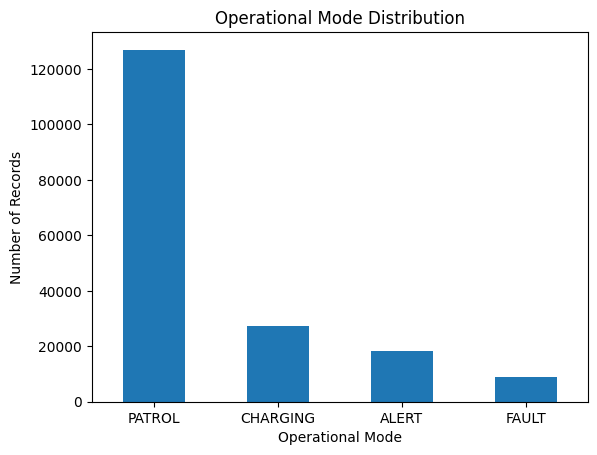

In [7]:
mode_counts.plot(kind="bar")

plt.title("Operational Mode Distribution")
plt.xlabel("Operational Mode")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.show()

### Missing Value Check

Check whether any telemetry features contain missing values before feature engineering and model training.

In [8]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage (%)": (df.isna().mean() * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
]

display(missing_summary)

,Missing Count,Missing Percentage (%)
latitude,3628,2.0
longitude,3628,2.0


## 2. Feature Engineering

Additional features are engineered from the raw telemetry to capture short-term battery behavior, robot movement, overall acceleration, and wheel balance.

The engineered features are:
- Battery SoC rolling mean
- Battery SoC rolling standard deviation
- GPS-derived speed
- IMU acceleration magnitude
- Wheel imbalance score

In [10]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df = df.sort_values(
    ["rover_id", "timestamp"]
).reset_index(drop=True)

display(df[["rover_id", "timestamp", "battery_soc"]].head())

,rover_id,timestamp,battery_soc
0,AIDO_001,2026-07-01 00:00:00,76.428284
1,AIDO_001,2026-07-01 00:05:00,76.275079
2,AIDO_001,2026-07-01 00:10:00,76.155109
3,AIDO_001,2026-07-01 00:15:00,76.014695
4,AIDO_001,2026-07-01 00:20:00,75.885342


### Battery Rolling Features

A 10-observation rolling window is used to summarize recent battery behavior for each Rover. With telemetry recorded at 5-minute intervals, the window captures 10 consecutive observations spanning approximately 45 minutes from the first to the last observation.

In [11]:
df["battery_soc_roll_mean"] = (
    df.groupby("rover_id")["battery_soc"]
      .transform(lambda x: x.rolling(window=10, min_periods=1).mean())
)

df["battery_soc_roll_std"] = (
    df.groupby("rover_id")["battery_soc"]
      .transform(lambda x: x.rolling(window=10, min_periods=2).std())
)

display(
    df[
        [
            "rover_id",
            "timestamp",
            "battery_soc",
            "battery_soc_roll_mean",
            "battery_soc_roll_std"
        ]
    ].head(12)
)

,rover_id,timestamp,battery_soc,battery_soc_roll_mean,battery_soc_roll_std
0,AIDO_001,2026-07-01 00:00:00,76.428284,76.428284,NaN
1,AIDO_001,2026-07-01 00:05:00,76.275079,76.351682,0.108332
2,AIDO_001,2026-07-01 00:10:00,76.155109,76.286157,0.136924
3,AIDO_001,2026-07-01 00:15:00,76.014695,76.218292,0.175846
4,AIDO_001,2026-07-01 00:20:00,75.885342,76.151702,0.212985
5,AIDO_001,2026-07-01 00:25:00,75.834123,76.098772,0.230433
6,AIDO_001,2026-07-01 00:30:00,75.741141,76.047682,0.250042
7,AIDO_001,2026-07-01 00:35:00,76.307956,76.080216,0.249113
8,AIDO_001,2026-07-01 00:40:00,76.206240,76.094219,0.236780
9,AIDO_001,2026-07-01 00:45:00,76.063807,76.091178,0.223445


### IMU Acceleration Magnitude

The three IMU acceleration axes are combined into a single magnitude feature representing the robot's overall acceleration intensity.

In [12]:
df["imu_magnitude"] = np.sqrt(
    df["imu_accel_x"] ** 2
    + df["imu_accel_y"] ** 2
    + df["imu_accel_z"] ** 2
)

display(
    df[
        [
            "imu_accel_x",
            "imu_accel_y",
            "imu_accel_z",
            "imu_magnitude"
        ]
    ].head()
)

,imu_accel_x,imu_accel_y,imu_accel_z,imu_magnitude
0,0.027548,0.065830,9.635538,9.635802
1,-0.209815,-0.043348,9.601425,9.603815
2,-0.009860,-0.163633,9.721586,9.722968
3,0.554334,-0.029707,9.735898,9.751711
4,-0.063300,-0.234918,10.039323,10.042270


### Wheel Imbalance Score

The wheel imbalance score summarizes how unevenly torque is distributed across the four wheels.

Higher values indicate greater variation in wheel torque, which may reflect unstable movement or abnormal wheel behavior.

In [13]:
wheel_cols = [
    "wheel_torque_fl",
    "wheel_torque_fr",
    "wheel_torque_rl",
    "wheel_torque_rr"
]

df["wheel_imbalance"] = df[wheel_cols].std(axis=1)

display(
    df[wheel_cols + ["wheel_imbalance"]].head()
)

,wheel_torque_fl,wheel_torque_fr,wheel_torque_rl,wheel_torque_rr,wheel_imbalance
0,15.488216,17.496137,18.483317,16.461332,1.293674
1,5.560991,19.340842,4.025754,12.218663,7.005753
2,35.108406,21.019085,15.790379,27.107367,8.307590
3,22.704654,16.397383,12.056365,20.362447,4.674495
4,24.153797,10.759237,13.542237,20.654680,6.194857


### GPS-Derived Speed

GPS-derived speed is calculated from the change in geographic position between consecutive observations for each Rover.

The Haversine formula is used to estimate the distance between consecutive latitude and longitude coordinates. Distance is divided by the elapsed time to obtain speed in meters per second.

In [14]:
df["prev_latitude"] = df.groupby("rover_id")["latitude"].shift(1)
df["prev_longitude"] = df.groupby("rover_id")["longitude"].shift(1)
df["prev_timestamp"] = df.groupby("rover_id")["timestamp"].shift(1)

display(
    df[
        [
            "rover_id",
            "timestamp",
            "latitude",
            "longitude",
            "prev_latitude",
            "prev_longitude"
        ]
    ].head(12)
)

,rover_id,timestamp,latitude,longitude,prev_latitude,prev_longitude
0,AIDO_001,2026-07-01 00:00:00,1.354202,103.821034,NaN,NaN
1,AIDO_001,2026-07-01 00:05:00,1.354486,103.820582,1.354202,103.821034
2,AIDO_001,2026-07-01 00:10:00,1.354647,103.820291,1.354486,103.820582
3,AIDO_001,2026-07-01 00:15:00,1.353859,103.821427,1.354647,103.820291
4,AIDO_001,2026-07-01 00:20:00,1.354567,103.820920,1.353859,103.821427
5,AIDO_001,2026-07-01 00:25:00,1.354120,103.821118,1.354567,103.820920
6,AIDO_001,2026-07-01 00:30:00,1.354076,103.820917,1.354120,103.821118
7,AIDO_001,2026-07-01 00:35:00,1.354429,103.820436,1.354076,103.820917
8,AIDO_001,2026-07-01 00:40:00,1.354606,103.821454,1.354429,103.820436
9,AIDO_001,2026-07-01 00:45:00,1.353826,103.821208,1.354606,103.821454


#### Haversine Distance

The Haversine formula converts the latitude and longitude difference between consecutive observations into an approximate geographic distance in meters.

In [15]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371000  # Earth radius in meters

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arctan2(
        np.sqrt(a),
        np.sqrt(1 - a)
    )

    return R * c

In [16]:
df["gps_distance_m"] = haversine_distance(
    df["prev_latitude"],
    df["prev_longitude"],
    df["latitude"],
    df["longitude"]
)

#### Convert GPS Distance to Speed

The distance between consecutive GPS observations is divided by the elapsed time to calculate Rover speed in meters per second.

In [17]:
df["time_diff_seconds"] = (
    df["timestamp"] - df["prev_timestamp"]
).dt.total_seconds()

df["gps_speed_mps"] = (
    df["gps_distance_m"] / df["time_diff_seconds"]
)

display(
    df[
        [
            "rover_id",
            "timestamp",
            "gps_distance_m",
            "time_diff_seconds",
            "gps_speed_mps"
        ]
    ].head(12)
)

,rover_id,timestamp,gps_distance_m,time_diff_seconds,gps_speed_mps
0,AIDO_001,2026-07-01 00:00:00,NaN,NaN,NaN
1,AIDO_001,2026-07-01 00:05:00,59.302468,300.0,0.197675
2,AIDO_001,2026-07-01 00:10:00,36.915991,300.0,0.123053
3,AIDO_001,2026-07-01 00:15:00,153.692214,300.0,0.512307
4,AIDO_001,2026-07-01 00:20:00,96.860713,300.0,0.322869
5,AIDO_001,2026-07-01 00:25:00,54.370610,300.0,0.181235
6,AIDO_001,2026-07-01 00:30:00,22.989622,300.0,0.076632
7,AIDO_001,2026-07-01 00:35:00,66.323994,300.0,0.221080
8,AIDO_001,2026-07-01 00:40:00,114.850871,300.0,0.382836
9,AIDO_001,2026-07-01 00:45:00,90.923065,300.0,0.303077


### Engineered Feature Summary

Review the newly created features before preparing the classification dataset.

In [18]:
engineered_features = [
    "battery_soc_roll_mean",
    "battery_soc_roll_std",
    "imu_magnitude",
    "wheel_imbalance",
    "gps_speed_mps"
]

display(df[engineered_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
battery_soc_roll_mean,181440.0,16.512125,25.971757,0.000000,0.165208,0.717672,28.175877,99.524755
battery_soc_roll_std,181410.0,0.966250,2.437762,0.000000,0.170562,0.235885,0.340345,17.382143
imu_magnitude,181440.0,10.115546,1.941327,0.671609,9.653469,9.829432,10.012161,44.548500
wheel_imbalance,181440.0,4.151453,3.481175,0.000000,2.075313,3.564969,5.189076,33.123298
gps_speed_mps,174223.0,0.197592,0.103436,0.000438,0.119413,0.185396,0.263035,0.832557


### Missing Values After Feature Engineering

Feature engineering can introduce additional missing values, particularly for rolling statistics and GPS-derived speed. Missingness is reviewed before constructing the model input dataset.

In [19]:
feature_missing = pd.DataFrame({
    "Missing Count": df[engineered_features].isna().sum(),
    "Missing Percentage (%)":
        (df[engineered_features].isna().mean() * 100).round(2)
})

display(feature_missing)

,Missing Count,Missing Percentage (%)
battery_soc_roll_mean,0,0.00
battery_soc_roll_std,30,0.02
imu_magnitude,0,0.00
wheel_imbalance,0,0.00
gps_speed_mps,7217,3.98


## 3. Feature Selection and Leakage Check

The classification target is `operational_mode`. Predictor variables are selected from raw sensor measurements and engineered telemetry features.

Columns that directly identify the Rover, represent time metadata, or may encode information too closely related to the generated target or injected anomalies are excluded to reduce target leakage.

In [20]:
print(df.columns.tolist())

['rover_id', 'timestamp', 'operational_mode', 'latitude', 'longitude', 'lidar_distance_m', 'wheel_torque_fl', 'wheel_torque_fr', 'wheel_torque_rl', 'wheel_torque_rr', 'imu_accel_x', 'imu_accel_y', 'imu_accel_z', 'ambient_temperature_c', 'battery_soc', 'task_success', 'gps_dropout_flag', 'lidar_saturation_flag', 'battery_drop_flag', 'sensor_noise_flag', 'battery_soc_roll_mean', 'battery_soc_roll_std', 'imu_magnitude', 'wheel_imbalance', 'prev_latitude', 'prev_longitude', 'prev_timestamp', 'gps_distance_m', 'time_diff_seconds', 'gps_speed_mps']


### Model Feature Set

The model uses raw telemetry measurements together with engineered features that summarize recent battery behavior, overall acceleration, wheel balance, and movement speed.

Identifiers, timestamps, target-related metadata, and anomaly ground-truth flags are excluded from the predictor set.

In [25]:
feature_columns = [
    # Raw telemetry
    "battery_soc",
    "lidar_distance_m",
    "wheel_torque_fl",
    "wheel_torque_fr",
    "wheel_torque_rl",
    "wheel_torque_rr",
    "imu_accel_x",
    "imu_accel_y",
    "imu_accel_z",
    "ambient_temperature_c",

    # Engineered features
    "battery_soc_roll_mean",
    "battery_soc_roll_std",
    "imu_magnitude",
    "wheel_imbalance",
    "gps_speed_mps"
]

target_column = "operational_mode"

print("Number of model features:", len(feature_columns))
print("\nFeatures:")
for feature in feature_columns:
    print("-", feature)

Number of model features: 15

Features:
- battery_soc
- lidar_distance_m
- wheel_torque_fl
- wheel_torque_fr
- wheel_torque_rl
- wheel_torque_rr
- imu_accel_x
- imu_accel_y
- imu_accel_z
- ambient_temperature_c
- battery_soc_roll_mean
- battery_soc_roll_std
- imu_magnitude
- wheel_imbalance
- gps_speed_mps


### Predictor Matrix and Target

`X` contains the selected telemetry features used by the classifiers, while `y` contains the operational mode labels to be predicted.

In [26]:
X = df[feature_columns].copy()
y = df[target_column].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

X shape: (181440, 15)
y shape: (181440,)


,battery_soc,lidar_distance_m,wheel_torque_fl,wheel_torque_fr,wheel_torque_rl,wheel_torque_rr,imu_accel_x,imu_accel_y,imu_accel_z,ambient_temperature_c,battery_soc_roll_mean,battery_soc_roll_std,imu_magnitude,wheel_imbalance,gps_speed_mps
0,76.428284,13.699527,15.488216,17.496137,18.483317,16.461332,0.027548,0.065830,9.635538,22.987241,76.428284,NaN,9.635802,1.293674,NaN
1,76.275079,0.486087,5.560991,19.340842,4.025754,12.218663,-0.209815,-0.043348,9.601425,21.239938,76.351682,0.108332,9.603815,7.005753,0.197675
2,76.155109,0.976473,35.108406,21.019085,15.790379,27.107367,-0.009860,-0.163633,9.721586,21.241867,76.286157,0.136924,9.722968,8.307590,0.123053
3,76.014695,6.150354,22.704654,16.397383,12.056365,20.362447,0.554334,-0.029707,9.735898,21.616087,76.218292,0.175846,9.751711,4.674495,0.512307
4,75.885342,12.263115,24.153797,10.759237,13.542237,20.654680,-0.063300,-0.234918,10.039323,21.213952,76.151702,0.212985,10.042270,6.194857,0.322869


## 4. Train/Test Split

The dataset is divided into 80% training data and 20% held-out test data using a stratified split.

Stratification preserves the operational mode distribution in both subsets, which is particularly important because the FAULT class is relatively rare.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_SEED
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (145152, 15)
Test set: (36288, 15)


### Verify Class Distribution

The class distributions in the training and test sets are compared to confirm that stratification preserved the original operational mode proportions.

In [28]:
distribution_check = pd.DataFrame({
    "Full Dataset (%)": y.value_counts(normalize=True) * 100,
    "Training Set (%)": y_train.value_counts(normalize=True) * 100,
    "Test Set (%)": y_test.value_counts(normalize=True) * 100
}).round(2)

display(distribution_check)

,Full Dataset (%),Training Set (%),Test Set (%)
PATROL,69.97,69.97,69.97
CHARGING,15.07,15.07,15.07
ALERT,10.01,10.01,10.01
FAULT,4.94,4.94,4.94


### Missing Value Imputation

Missing feature values are replaced using medians calculated from the training set only. The same training-set medians are then applied to the held-out test set to prevent information leakage.

In [29]:
train_medians = X_train.median()

X_train = X_train.fillna(train_medians)
X_test = X_test.fillna(train_medians)

print("Missing values in training set:", X_train.isna().sum().sum())
print("Missing values in test set:", X_test.isna().sum().sum())

Missing values in training set: 0
Missing values in test set: 0


## 5. Baseline Models

Before training the Random Forest and Logistic Regression classifiers, two simple baseline models are evaluated.

- **Majority-class baseline:** always predicts the most common operational mode.
- **Random baseline:** generates predictions according to the class distribution in the training data.

These baselines provide reference performance levels for evaluating whether the machine learning models learn meaningful patterns from the telemetry features.

### Majority-Class Baseline

The majority-class baseline always predicts the most frequent operational mode in the training dataset. This establishes a minimum benchmark based solely on class imbalance.

In [30]:
majority_baseline = DummyClassifier(
    strategy="most_frequent"
)

majority_baseline.fit(X_train, y_train)

majority_pred = majority_baseline.predict(X_test)

majority_accuracy = accuracy_score(y_test, majority_pred)
majority_f1 = f1_score(
    y_test,
    majority_pred,
    average="macro"
)

print(f"Majority Baseline Accuracy: {majority_accuracy:.4f}")
print(f"Majority Baseline Macro-F1: {majority_f1:.4f}")

Majority Baseline Accuracy: 0.6997
Majority Baseline Macro-F1: 0.2058


### Random Baseline

The random baseline generates predictions according to the operational mode distribution observed in the training data. It provides a chance-level reference while preserving the class imbalance of the dataset.

In [31]:
random_baseline = DummyClassifier(
    strategy="stratified",
    random_state=RANDOM_SEED
)

random_baseline.fit(X_train, y_train)

random_pred = random_baseline.predict(X_test)

random_accuracy = accuracy_score(y_test, random_pred)
random_f1 = f1_score(
    y_test,
    random_pred,
    average="macro"
)

print(f"Random Baseline Accuracy: {random_accuracy:.4f}")
print(f"Random Baseline Macro-F1: {random_f1:.4f}")

Random Baseline Accuracy: 0.5264
Random Baseline Macro-F1: 0.2488


### Baseline Performance Comparison

Accuracy and macro-F1 are compared across the two baseline strategies. Because the dataset is imbalanced, macro-F1 provides a more informative measure of performance across all four operational modes.

In [32]:
baseline_results = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Random Baseline"
    ],
    "Accuracy": [
        majority_accuracy,
        random_accuracy
    ],
    "Macro-F1": [
        majority_f1,
        random_f1
    ]
})

display(
    baseline_results.round(4)
)

,Model,Accuracy,Macro-F1
0,Majority Baseline,0.6997,0.2058
1,Random Baseline,0.5264,0.2488


## 6. Random Forest Classifier

A Random Forest classifier is trained using 100 decision trees with no initial maximum depth constraint.

The model is evaluated on the held-out test set using accuracy, macro-F1, multiclass ROC-AUC, and a confusion matrix.

In [33]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

### Random Forest Predictions

The trained Random Forest is applied to the held-out test set to generate predicted operational mode labels and class probabilities.

In [34]:
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)

### Random Forest Performance

Accuracy measures overall prediction correctness, while macro-F1 gives equal importance to each operational mode and is therefore particularly useful for evaluating performance on the imbalanced dataset.

In [48]:
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average="macro"
)

rf_auc = roc_auc_score(
    y_test,
    rf_proba,
    multi_class="ovr",
    average="macro",
    labels=rf_model.classes_
)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Random Forest Macro-F1: {rf_f1:.4f}")
print(f"Random Forest Macro ROC-AUC: {rf_auc:.4f}")

Random Forest Accuracy: 0.9672
Random Forest Macro-F1: 0.9327
Random Forest Macro ROC-AUC: 0.9880


### Per-Class Random Forest Performance

Precision, recall, and F1-score are examined separately for each operational mode to identify which classes are more difficult for the Random Forest to distinguish.

In [36]:
print(
    classification_report(
        y_test,
        rf_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

       ALERT     0.9253    0.8654    0.8943      3633
    CHARGING     0.9931    0.9989    0.9960      5470
       FAULT     0.9401    0.7970    0.8627      1793
      PATROL     0.9688    0.9870    0.9778     25392

    accuracy                         0.9672     36288
   macro avg     0.9568    0.9121    0.9327     36288
weighted avg     0.9667    0.9672    0.9665     36288



### Random Forest Confusion Matrix

The confusion matrix shows how predicted operational modes compare with the true labels in the held-out test set.

This analysis helps identify which operational modes are most frequently confused and whether the errors have a plausible operational explanation.

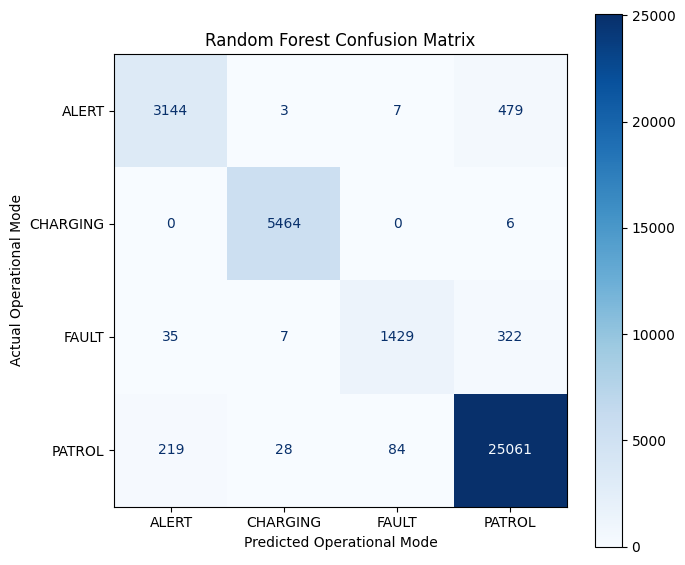

In [38]:
fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    labels=rf_model.classes_,
    cmap="Blues",
    values_format="d",
    ax=ax
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Operational Mode")
plt.ylabel("Actual Operational Mode")
plt.tight_layout()
plt.show()

**Interpretation:**  
The Random Forest performs strongly across all four operational modes. CHARGING is the most clearly separated class, with 5,464 of 5,470 observations correctly classified. The largest error pattern occurs between ALERT and PATROL, with 479 ALERT observations classified as PATROL. FAULT is also sometimes confused with PATROL, with 322 FAULT observations classified as PATROL. This contributes to FAULT having the lowest recall among the four classes.

## 7. Logistic Regression Classifier

Logistic Regression is trained as a simpler linear classification model using the same telemetry features and train/test split as the Random Forest.

Because Logistic Regression is sensitive to differences in feature scale, the predictor variables are standardized using statistics learned from the training set only.

### Feature Standardization

The training features are standardized to have approximately zero mean and unit variance. The scaler is fitted only on the training data and then applied to both the training and test sets to prevent data leakage.

In [41]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled training shape: (145152, 15)
Scaled test shape: (36288, 15)


### Train Logistic Regression

A multiclass Logistic Regression model is trained on the standardized training features.

In [42]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_SEED
)

lr_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### Logistic Regression Predictions

The trained Logistic Regression model is applied to the standardized held-out test set to generate class predictions and predicted probabilities.

In [43]:
lr_pred = lr_model.predict(X_test_scaled)
lr_proba = lr_model.predict_proba(X_test_scaled)

### Logistic Regression Performance

The Logistic Regression classifier is evaluated using the same metrics as the Random Forest to allow direct model comparison.

In [44]:
lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

lr_f1 = f1_score(
    y_test,
    lr_pred,
    average="macro"
)

lr_auc = roc_auc_score(
    y_test,
    lr_proba,
    multi_class="ovr",
    average="macro",
    labels=lr_model.classes_
)

print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")
print(f"Logistic Regression Macro-F1: {lr_f1:.4f}")
print(f"Logistic Regression Macro ROC-AUC: {lr_auc:.4f}")

Logistic Regression Accuracy: 0.8839
Logistic Regression Macro-F1: 0.7384
Logistic Regression Macro ROC-AUC: 0.9388


### Per-Class Logistic Regression Performance

Per-class precision, recall, and F1-score are examined to identify which operational modes are more difficult for the linear classifier to distinguish.

In [45]:
print(
    classification_report(
        y_test,
        lr_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

       ALERT     0.6573    0.2064    0.3142      3633
    CHARGING     0.9749    0.9505    0.9625      5470
       FAULT     0.9089    0.6397    0.7509      1793
      PATROL     0.8749    0.9837    0.9261     25392

    accuracy                         0.8839     36288
   macro avg     0.8540    0.6951    0.7384     36288
weighted avg     0.8698    0.8839    0.8617     36288



### Logistic Regression Confusion Matrix

The confusion matrix shows the classification errors made by Logistic Regression and allows direct comparison with the Random Forest error patterns.

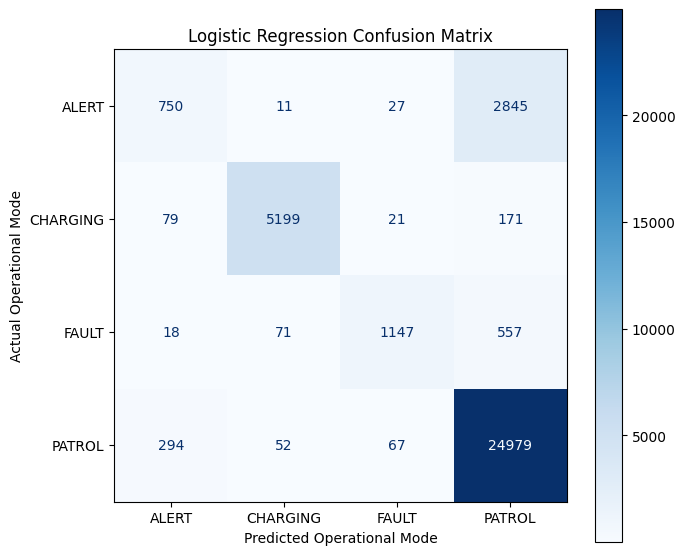

In [46]:
fig, ax = plt.subplots(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_pred,
    labels=lr_model.classes_,
    cmap="Blues",
    values_format="d",
    ax=ax
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Operational Mode")
plt.ylabel("Actual Operational Mode")
plt.tight_layout()
plt.show()

**Interpretation:**  
Logistic Regression shows substantially more confusion between ALERT and PATROL than Random Forest. Of the 3,633 actual ALERT observations, only 750 were correctly classified, while 2,845 were predicted as PATROL. FAULT was also frequently confused with PATROL, with 557 FAULT observations assigned to PATROL. In contrast, CHARGING and PATROL were identified more reliably. These results indicate that the linear Logistic Regression model has greater difficulty separating ALERT and FAULT from the dominant PATROL class.

## 8. Model Comparison

The two baseline models and the two trained classifiers are compared using accuracy and macro-F1. ROC-AUC is additionally reported for the trained classifiers that produce meaningful class probability estimates.

In [49]:
model_results = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Random Baseline",
        "Random Forest",
        "Logistic Regression"
    ],

    "Accuracy": [
        majority_accuracy,
        random_accuracy,
        rf_accuracy,
        lr_accuracy
    ],

    "Macro-F1": [
        majority_f1,
        random_f1,
        rf_f1,
        lr_f1
    ],

    "Macro ROC-AUC": [
        np.nan,
        np.nan,
        rf_auc,
        lr_auc
    ]
})

display(model_results.round(4))

,Model,Accuracy,Macro-F1,Macro ROC-AUC
0,Majority Baseline,0.6997,0.2058,NaN
1,Random Baseline,0.5264,0.2488,NaN
2,Random Forest,0.9672,0.9327,0.9880
3,Logistic Regression,0.8839,0.7384,0.9388


## 9. Classification Model Summary

Random Forest achieved the strongest overall classification performance, with an accuracy of **0.9672**, macro-F1 of **0.9327**, and macro ROC-AUC of **0.9880**. These results substantially exceeded both baseline models and the Logistic Regression classifier.

Logistic Regression achieved an accuracy of **0.8839**, but its lower macro-F1 of **0.7384** indicates less consistent performance across the four operational modes. Its largest error pattern occurred between ALERT and PATROL, with 2,845 ALERT observations classified as PATROL.

Random Forest substantially reduced this confusion, misclassifying only 479 ALERT observations as PATROL. It also improved FAULT detection, although FAULT remained the most difficult class for the Random Forest, with a recall of 0.7970.

Overall, the results suggest that Random Forest captures operational patterns in the synthetic telemetry more effectively than the linear Logistic Regression model. The next analysis examines Random Forest feature importance to identify which telemetry variables contribute most strongly to operational mode classification.